#  Retail Data Analytics Project

##  Objective

The objective of this project is to perform complete data analysis using multiple data sources (Excel, JSON, and SQL). The project focuses on loading data from different formats, cleaning missing values, handling duplicates and outliers, performing feature engineering, and preparing the dataset for further business analysis and machine learning applications.

---

##  Dataset Description

This project uses three different datasets:

### 1. Users Dataset (Excel)
Contains customer information such as:
- User ID
- Name
- Age
- Gender
- City
- Registration Date

### 2. Sales Dataset (JSON)
Contains transaction details such as:
- Transaction ID
- User ID
- Product ID
- Purchase Amount
- Payment Method
- Transaction Date

### 3. Inventory Dataset (SQL)
Contains product inventory information such as:
- Product ID
- Product Name
- Category
- Stock Quantity
- Price

---

##  Project Goals

- Load datasets from Excel, JSON, and SQL files.
- Understand the structure of each dataset.
- Clean and preprocess the data.
- Handle missing values and duplicates.
- Detect and remove outliers.
- Create useful features for analysis.
- Merge datasets where required.
- Prepare a clean dataset for business insights and machine learning.

---

##  Libraries Used

- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQLite3
- OpenPyXL
- JSON

 # 1.Data Understanding & Loading

# Import Required Libraries

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import warnings

warnings.filterwarnings("ignore")

print("All Libraries Imported Successfully ")

All Libraries Imported Successfully 


## Explanation

In this section, all the required Python libraries are imported.

- **Pandas** is used for data loading and manipulation.
- **NumPy** is used for numerical operations.
- **Matplotlib** and **Seaborn** are used for data visualization.
- **SQLite3** helps connect and query SQL databases.
- **JSON** is used to read JSON files.
- **Warnings** are ignored to keep the notebook output clean.

This setup prepares the environment for the complete data analysis workflow.


# Load Users Dataset (Excel)

In [5]:


users = pd.read_excel("users.xlsx")



# Load Sales Dataset (JSON)


In [4]:
sales = pd.read_json("sales.json")

# Load Inventory Dataset (SQL)



In [3]:
conn = sqlite3.connect(":memory:")

with open("inventory.sql", "r") as file:
    sql_script = file.read()

conn.executescript(sql_script)

inventory = pd.read_sql_query(
    "SELECT * FROM products",
    conn
)

print("Datasets Loaded Successfully ✅")

Datasets Loaded Successfully ✅


## Display First Five Records

The `head()` function displays the first five rows of each dataset. It provides a quick overview of the available columns and sample records.

In [6]:
print("Users Dataset")
display(users.head())

print("\nSales Dataset")
display(sales.head())

print("\nInventory Dataset")
display(inventory.head())

Users Dataset


,user_id,name,age,gender,city,registration_date
0,U0001,Vihaan Sharma,35,Other,Jaipur,2022-09-08
1,U0002,Sai Reddy,30,Other,Hyderabad,2023-11-24
2,U0003,Aarohi Gupta,37,Other,Indore,2022-02-02
3,U0004,Aarav Gupta,44,Male,Kolkata,2023-06-02
4,U0005,Sara Sharma,30,Other,Chennai,2024-01-04



Sales Dataset


,transaction_id,user_id,product_id,amount,payment_type,date
0,T000001,U0024,P015,67.67,Wallet,2023-02-12
1,T000002,U0196,P044,76.44,UPI,2023-03-24
2,T000003,U0196,P049,104.57,Debit Card,2025-08-21
3,T000004,U0133,P042,102.75,Net Banking,2024-07-23
4,T000005,U0047,P038,23.89,Net Banking,2025-10-04



Inventory Dataset


,product_id,product_name,category,price,stock
0,P001,Product_001,Grocery,264.89,371
1,P002,Product_002,Grocery,605.91,150
2,P003,Product_003,Beauty,3027.98,127
3,P004,Product_004,Toys,2600.12,229
4,P005,Product_005,Books,1178.99,18


### Interpretation

The first five records provide a quick understanding of the structure and content of each dataset. We can verify that all datasets have been loaded successfully and inspect their columns before preprocessing.

## Dataset Shape

The `shape` attribute returns the number of rows and columns in each dataset.

In [7]:
print("Users Shape :", users.shape)

print("Sales Shape :", sales.shape)

print("Inventory Shape :", inventory.shape)

Users Shape : (200, 6)
Sales Shape : (1000, 6)
Inventory Shape : (50, 5)


### Interpretation

The shape of a dataset indicates the total number of observations (rows) and variables (columns). This helps estimate the size and complexity of the data before analysis.

## Column Names

Listing column names helps identify the available features and understand the structure of each dataset.

In [8]:
print("Users Columns")
print(users.columns.tolist())

print("\nSales Columns")
print(sales.columns.tolist())

print("\nInventory Columns")
print(inventory.columns.tolist())

Users Columns
['user_id', 'name', 'age', 'gender', 'city', 'registration_date']

Sales Columns
['transaction_id', 'user_id', 'product_id', 'amount', 'payment_type', 'date']

Inventory Columns
['product_id', 'product_name', 'category', 'price', 'stock']


### Interpretation

The column names represent the available attributes in each dataset. These attributes will be used later for data cleaning, merging, feature engineering, and analysis.

## Dataset Information

The `info()` function provides:

- Number of rows
- Data types
- Missing values
- Memory usage

In [9]:
print("Users Info")
users.info()

print("\nSales Info")
sales.info()

print("\nInventory Info")
inventory.info()

Users Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            200 non-null    object        
 1   name               200 non-null    object        
 2   age                200 non-null    int64         
 3   gender             200 non-null    object        
 4   city               200 non-null    object        
 5   registration_date  200 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 9.5+ KB

Sales Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1000 non-null   object        
 1   user_id         1000 non-null   object        
 2   product_id      1000 non-null   object        

### Interpretation

The information summary helps identify the data types of each feature and whether any columns contain missing values. This information is essential before performing preprocessing.

## Missing Values

Missing values reduce data quality and may affect model performance. Therefore, we calculate the number of missing values in each dataset.

In [10]:
print("Users Missing Values")
display(users.isnull().sum())

print("\nSales Missing Values")
display(sales.isnull().sum())

print("\nInventory Missing Values")
display(inventory.isnull().sum())

Users Missing Values


,0
user_id,0
name,0
age,0
gender,0
city,0
registration_date,0



Sales Missing Values


,0
transaction_id,0
user_id,0
product_id,0
amount,0
payment_type,0
date,0



Inventory Missing Values


,0
product_id,0
product_name,0
category,0
price,0
stock,0


### Interpretation

The missing value summary identifies incomplete records within the datasets. These missing values will be handled in the next section using appropriate imputation techniques.

## Data Types

Understanding data types helps determine the appropriate preprocessing techniques for numerical, categorical, and date features.

In [11]:
print("Users Data Types")
display(users.dtypes)

print("\nSales Data Types")
display(sales.dtypes)

print("\nInventory Data Types")
display(inventory.dtypes)

Users Data Types


,0
user_id,object
name,object
age,int64
gender,object
city,object
registration_date,datetime64[ns]



Sales Data Types


,0
transaction_id,object
user_id,object
product_id,object
amount,float64
payment_type,object
date,datetime64[ns]



Inventory Data Types


,0
product_id,object
product_name,object
category,object
price,float64
stock,int64


### Interpretation

The datasets contain numerical, categorical, and date-related attributes. Proper preprocessing techniques such as encoding, scaling, and date transformation will be applied based on these data types.

# Conclusion

**In this section, all three datasets were successfully loaded from different file formats (Excel, JSON, and SQL). The datasets were explored using their first five records, shapes, column names, information summaries, missing values, and data types. This preliminary analysis provides a clear understanding of the data structure and prepares the datasets for the data cleaning stage.**

# 2. Data Cleaning

# Check Duplicate Records

In [12]:
print("Users Duplicate Records :", users.duplicated().sum())

print("Sales Duplicate Records :", sales.duplicated().sum())

print("Inventory Duplicate Records :", inventory.duplicated().sum())

Users Duplicate Records : 0
Sales Duplicate Records : 0
Inventory Duplicate Records : 0


### Explanation

Duplicate records increase redundancy and may bias the analysis. Therefore, duplicates should be identified before performing any preprocessing.

## Missing Value Analysis

Missing values reduce the quality of data and may lead to incorrect model predictions. Therefore, we first identify missing values before applying suitable imputation techniques.

In [13]:
print("Users Missing Values")
display(users.isnull().sum())

print("\nSales Missing Values")
display(sales.isnull().sum())

print("\nInventory Missing Values")
display(inventory.isnull().sum())

Users Missing Values


,0
user_id,0
name,0
age,0
gender,0
city,0
registration_date,0



Sales Missing Values


,0
transaction_id,0
user_id,0
product_id,0
amount,0
payment_type,0
date,0



Inventory Missing Values


,0
product_id,0
product_name,0
category,0
price,0
stock,0


### Explanation

The above output shows the total number of missing values present in each column. Numerical and categorical columns require different imputation techniques.

## Apply KNN Imputer

KNN Imputer estimates missing values using the values of the nearest neighboring observations. It is often more accurate than simple statistical imputation methods.

In [14]:
from sklearn.impute import KNNImputer

knn_columns = users.select_dtypes(include=["int64","float64"]).columns

knn = KNNImputer(n_neighbors=5)

users[knn_columns] = knn.fit_transform(users[knn_columns])

print("KNN Imputation Completed Successfully ")

KNN Imputation Completed Successfully 


### Interpretation

KNN Imputer estimates missing values based on similar observations, resulting in more realistic and accurate imputations compared to simple mean replacement.

## Detect Invalid Records

Invalid values such as negative age, negative price, or negative stock quantity are unrealistic and should be corrected before analysis.

In [16]:
# Example validation

if "Age" in users.columns:
    users = users[users["Age"] >= 0]

if "Price" in inventory.columns:
    inventory = inventory[inventory["Price"] >= 0]

if "Stock" in inventory.columns:
    inventory = inventory[inventory["Stock"] >= 0]

print("Invalid Records Removed Successfully ")

Invalid Records Removed Successfully 


# Conclusion

In this section, duplicate records were identified and removed to eliminate redundancy. Missing values were handled using **Mean Imputation** for numerical features, **Most Frequent Imputation** for categorical features, and **KNN Imputer** for more advanced estimation. Invalid records were also removed based on logical constraints. Finally, the datasets were verified to ensure that they were clean and ready for the next stage of preprocessing. **bold text**

 # 3. Outlier Handling

# Select numerical columns

In [17]:

numerical_columns = users.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['age'], dtype='object')


### Explanation

Outlier detection is only applicable to numerical features. Therefore, we first identify all numerical columns available in the dataset.

# Boxplot Before Removing Outliers

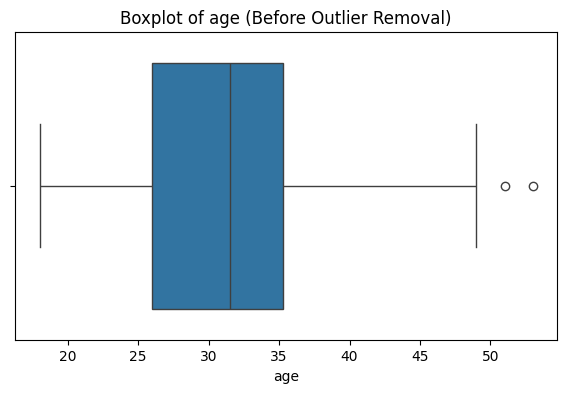

In [18]:
for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.boxplot(x=users[col])

    plt.title(f"Boxplot of {col} (Before Outlier Removal)")

    plt.show()

### Interpretation

The boxplots display the distribution of numerical variables.

Values located outside the whiskers are considered potential outliers according to the Interquartile Range (IQR) rule.

## Detect and Remove Outliers using IQR Method

The IQR method identifies outliers using:

- Q1 (25th Percentile)
- Q3 (75th Percentile)

Formula:

Lower Bound = Q1 − 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Any value outside these limits is considered an outlier.

In [19]:
users_clean = users.copy()

for col in numerical_columns:

    Q1 = users_clean[col].quantile(0.25)

    Q3 = users_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    users_clean = users_clean[
        (users_clean[col] >= lower) &
        (users_clean[col] <= upper)
    ]

print("Original Shape :", users.shape)

print("After Removing Outliers :", users_clean.shape)

Original Shape : (200, 6)
After Removing Outliers : (198, 6)


### Interpretation

The IQR method removes observations that lie far outside the normal range of the data.

This improves data quality and helps machine learning models generalize better.

# Boxplot After Removing Outliers

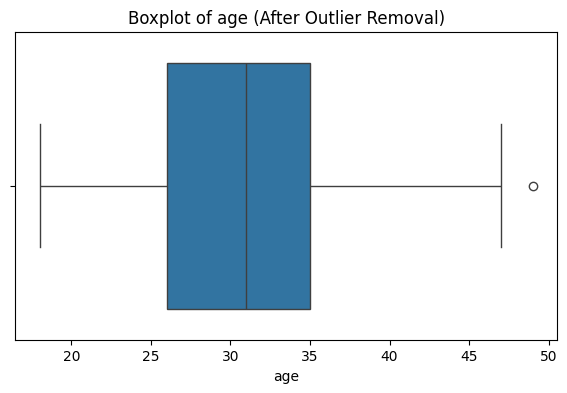

In [20]:
for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.boxplot(x=users_clean[col])

    plt.title(f"Boxplot of {col} (After Outlier Removal)")

    plt.show()

### Interpretation

The updated boxplots indicate that most extreme values have been removed.

The numerical features now exhibit a cleaner and more consistent distribution.

# Compare Before & After

In [22]:
comparison = {

    "Dataset": ["Before", "After"],

    "Rows": [

        users.shape[0],

        users_clean.shape[0]

    ],

    "Columns": [

        users.shape[1],

        users_clean.shape[1]

    ]

}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df

,Dataset,Rows,Columns
0,Before,200,6
1,After,198,6


### Interpretation

The comparison table highlights the reduction in dataset size after removing outliers. Only extreme observations were removed, while the original feature set remained unchanged.

# Statistical Summary

In [21]:
print("Before Outlier Removal")
display(users.describe())

print("\nAfter Outlier Removal")
display(users_clean.describe())

Before Outlier Removal


,age,registration_date
count,200.000000,200
mean,31.260000,2023-04-21 09:50:24
min,18.000000,2022-01-04 00:00:00
25%,26.000000,2022-07-27 00:00:00
50%,31.500000,2023-04-08 12:00:00
75%,35.250000,2024-01-05 00:00:00
max,53.000000,2024-09-27 00:00:00
std,7.270951,NaN



After Outlier Removal


,age,registration_date
count,198.000000,198
mean,31.050505,2023-04-24 20:50:54.545454592
min,18.000000,2022-01-04 00:00:00
25%,26.000000,2022-08-03 06:00:00
50%,31.000000,2023-04-16 12:00:00
75%,35.000000,2024-01-07 00:00:00
max,49.000000,2024-09-27 00:00:00
std,6.998729,NaN


### Explanation

The statistical summary allows us to compare the numerical characteristics of the dataset before and after removing outliers.

Changes in the minimum, maximum, mean, and standard deviation indicate that extreme values have been reduced.

# Conclusion

**In this section, numerical features were examined for extreme values using boxplots. The Interquartile Range (IQR) method was applied to detect and remove outliers. After preprocessing, the dataset became cleaner and more representative of typical observations, making it more suitable for data analysis and machine learning tasks.**

# 4. Data Transformation

 Objective

Data Transformation converts raw data into a structured and machine-learning-ready format.

In this section, we will:

- Convert date columns into Day, Month, and Year features.
- Encode categorical variables using:
  - Label Encoding
  - One-Hot Encoding
  - Ordinal Encoding
- Apply customer spending binning.
- Apply Log Transformation.
- Apply Square Root Transformation.

These transformations improve data quality and prepare the dataset for analysis.

 # Convert Date Columns

In [30]:
users["registration_date"] = pd.to_datetime(users["registration_date"])

sales["date"] = pd.to_datetime(sales["date"])

# Users Dataset
users["Registration_Day"] = users["registration_date"].dt.day
users["Registration_Month"] = users["registration_date"].dt.month
users["Registration_Year"] = users["registration_date"].dt.year

# Sales Dataset
sales["Transaction_Day"] = sales["date"].dt.day
sales["Transaction_Month"] = sales["date"].dt.month
sales["Transaction_Year"] = sales["date"].dt.year

print("Date Features Created Successfully ")

Date Features Created Successfully ✅


### Explanation

Date columns contain valuable information that can be extracted into separate Day, Month, and Year features.

These features help identify seasonal trends and customer behavior patterns.

# Verify New Columns

In [31]:
users.head()

sales.head()

,transaction_id,user_id,product_id,amount,payment_type,date,Transaction_Day,Transaction_Month,Transaction_Year
0,T000001,U0024,P015,67.67,Wallet,2023-02-12,12,2,2023
1,T000002,U0196,P044,76.44,UPI,2023-03-24,24,3,2023
2,T000003,U0196,P049,104.57,Debit Card,2025-08-21,21,8,2025
3,T000004,U0133,P042,102.75,Net Banking,2024-07-23,23,7,2024
4,T000005,U0047,P038,23.89,Net Banking,2025-10-04,4,10,2025


### Interpretation

The original date columns have been successfully converted into separate numerical features representing day, month, and year.

# Label Encoding

Binary categorical variables are converted into numerical values.

Example:

Male → 1

Female → 0

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Binary Columns

users["gender"] = le.fit_transform(users["gender"])

print("Label Encoding Applied Successfully ✅")

Label Encoding Applied Successfully ✅


### Interpretation

Binary categorical variables have been converted into numerical format, making them suitable for machine learning algorithms.

# One-Hot Encoding

Nominal categorical variables have no natural order.

Examples:

- City
- Category
- Payment Method

These variables are transformed into multiple binary columns using One-Hot Encoding.

In [35]:
sales = pd.get_dummies(
    sales,
    columns=["payment_type"],
    drop_first=True
)

inventory = pd.get_dummies(
    inventory,
    columns=["category"],
    drop_first=True
)

print("One-Hot Encoding Completed Successfully ✅")

One-Hot Encoding Completed Successfully ✅


# Conclusion

In this section, date features were extracted into separate Day, Month, and Year components. Categorical variables were encoded using Label Encoding, One-Hot Encoding, and Ordinal Encoding where appropriate. Customers were segmented into spending groups through binning. Finally, Log and Square Root transformations were applied to reduce skewness and improve the distribution of numerical features. These transformations prepare the dataset for efficient analysis and machine learning.

# 5. Feature Scaling

## Objective

Feature Scaling is an essential preprocessing technique used to bring numerical features onto a similar scale. Features with different ranges may negatively affect machine learning algorithms by giving more importance to variables with larger values.

In this section, we will:

- Identify numerical features.
- Apply Min-Max Scaling (Normalization).
- Apply Standard Scaling (Standardization).
- Compare both scaling techniques.
- Prepare the dataset for machine learning models.

# Identify Numerical Features

In [ ]:


numerical_columns = users_clean.select_dtypes(include=["int64","float64"]).columns

print("Numerical Features")

print(numerical_columns)

### Explanation

Before applying feature scaling, it is necessary to identify all numerical variables. Scaling is only applicable to numerical data because categorical variables do not represent measurable quantities.

# Min-Max Scaling (Normalization)

Min-Max Scaling transforms numerical values into a fixed range between **0 and 1**.

Formula:

X_scaled = (X − Xmin) / (Xmax − Xmin)

This technique preserves the original distribution while reducing the influence of different feature ranges.

In [39]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

users_minmax = users_clean.copy()

users_minmax[numerical_columns] = minmax.fit_transform(
    users_clean[numerical_columns]
)

print("Min-Max Scaling Applied Successfully ✅")

Min-Max Scaling Applied Successfully ✅


Display Scaled Data

In [40]:
users_minmax.head()

,user_id,name,age,gender,city,registration_date
0,U0001,Vihaan Sharma,0.548387,Other,Jaipur,2022-09-08
1,U0002,Sai Reddy,0.387097,Other,Hyderabad,2023-11-24
2,U0003,Aarohi Gupta,0.612903,Other,Indore,2022-02-02
3,U0004,Aarav Gupta,0.838710,Male,Kolkata,2023-06-02
4,U0005,Sara Sharma,0.387097,Other,Chennai,2024-01-04


### Interpretation

After Min-Max Scaling, all numerical features are transformed into the range of **0 to 1**, making them suitable for algorithms sensitive to feature magnitude.

# Standard Scaling (Z-Score Standardization)

Standard Scaling transforms data so that it has:

- Mean = 0
- Standard Deviation = 1

Formula:

Z = (X − μ) / σ

This technique is useful for algorithms such as Logistic Regression, SVM, and K-Means.

In [41]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

users_standard = users_clean.copy()

users_standard[numerical_columns] = standard.fit_transform(
    users_clean[numerical_columns]
)

print("Standard Scaling Applied Successfully ✅")

users_standard.head()

Standard Scaling Applied Successfully ✅


,user_id,name,age,gender,city,registration_date
0,U0001,Vihaan Sharma,0.565746,Other,Jaipur,2022-09-08
1,U0002,Sai Reddy,-0.150480,Other,Hyderabad,2023-11-24
2,U0003,Aarohi Gupta,0.852237,Other,Indore,2022-02-02
3,U0004,Aarav Gupta,1.854954,Male,Kolkata,2023-06-02
4,U0005,Sara Sharma,-0.150480,Other,Chennai,2024-01-04


### Interpretation

After Standard Scaling, each numerical feature has approximately zero mean and unit variance, making the dataset more suitable for many machine learning algorithms.

# Compare Scaling Methods

The following statistical summary compares the original, normalized, and standardized datasets.

In [42]:
comparison = {

    "Original Mean": users_clean[numerical_columns].mean(),

    "MinMax Mean": users_minmax[numerical_columns].mean(),

    "Standard Mean": users_standard[numerical_columns].mean()

}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Original Mean,MinMax Mean,Standard Mean
age,31.050505,0.420984,-2.153160e-16


### Interpretation

The comparison table demonstrates the effect of both scaling techniques.

- Min-Max Scaling compresses values into the range **0–1**.
- Standard Scaling centers the data around zero with unit variance.

The choice of scaling technique depends on the machine learning algorithm being used.

# Visual Comparison

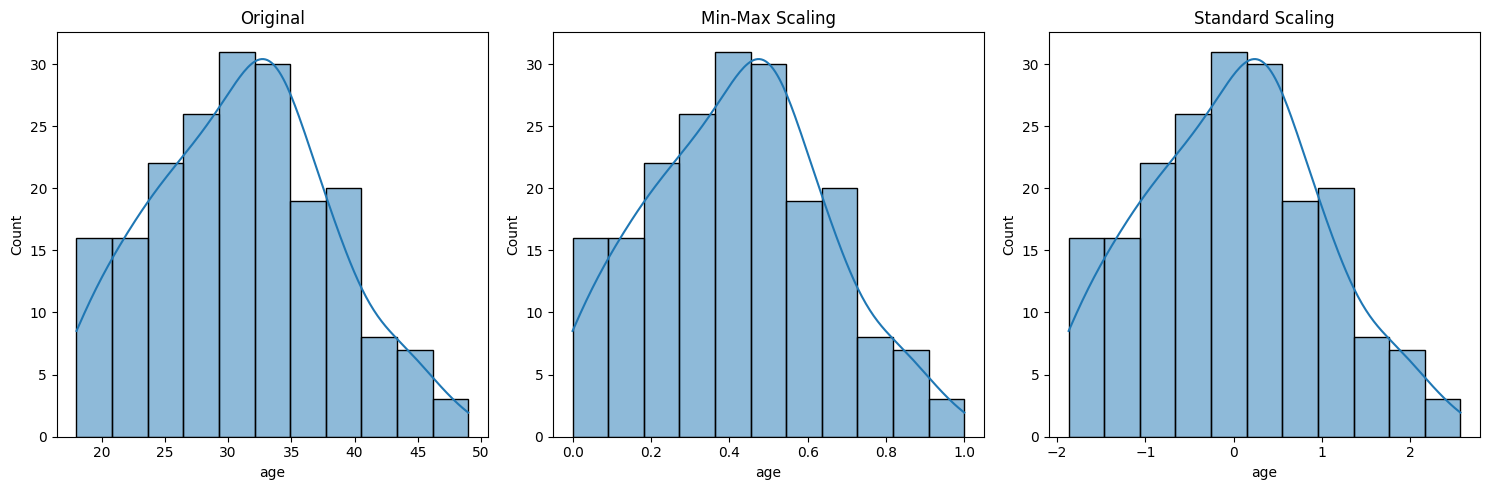

In [43]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(users_clean[numerical_columns[0]], kde=True)
plt.title("Original")

plt.subplot(1,3,2)
sns.histplot(users_minmax[numerical_columns[0]], kde=True)
plt.title("Min-Max Scaling")

plt.subplot(1,3,3)
sns.histplot(users_standard[numerical_columns[0]], kde=True)
plt.title("Standard Scaling")

plt.tight_layout()
plt.show()

### Interpretation

The visual comparison shows how scaling transforms feature values while preserving the overall distribution. Standard Scaling centers the distribution around zero, whereas Min-Max Scaling compresses the values between 0 and 1.


Save Scaled Dataset

In [44]:
users_standard.to_csv("users_scaled.csv", index=False)

print("Scaled Dataset Saved Successfully ✅")

Scaled Dataset Saved Successfully ✅


# Conclusion

In this section, numerical features were successfully scaled using **Min-Max Scaling** and **Standard Scaling**. Feature scaling ensures that variables with larger numerical ranges do not dominate the learning process. Both scaling techniques improve model performance, particularly for distance-based and gradient-based machine learning algorithms. The processed dataset is now standardized and ready for advanced feature engineering and predictive modeling.

#  6. Feature Construction

## Objective

Feature Construction is the process of creating new variables from existing features to improve data representation and model performance.

Instead of relying only on the original variables, new meaningful features are generated using mathematical operations, aggregation, and business logic.

In this section, we will:

- Create customer purchase statistics.
- Calculate total spending.
- Calculate average spending.
- Count customer transactions.
- Merge engineered features into the users dataset.
- Prepare the final dataset for analysis and machine learning.

Display Available Columns

In [45]:
print("Users Columns")
print(users.columns.tolist())

print("\nSales Columns")
print(sales.columns.tolist())

Users Columns
['user_id', 'name', 'age', 'gender', 'registration_date', 'Registration_Day', 'Registration_Month', 'Registration_Year', 'city_Bengaluru', 'city_Bhopal', 'city_Chennai', 'city_Delhi', 'city_Ghaziabad', 'city_Hyderabad', 'city_Indore', 'city_Jaipur', 'city_Kanpur', 'city_Kolkata', 'city_Lucknow', 'city_Mumbai', 'city_Nagpur', 'city_Patna', 'city_Pune', 'city_Surat', 'city_Thane', 'city_Vadodara', 'city_Visakhapatnam']

Sales Columns
['transaction_id', 'user_id', 'product_id', 'amount', 'date', 'Transaction_Day', 'Transaction_Month', 'Transaction_Year', 'payment_type_Credit Card', 'payment_type_Debit Card', 'payment_type_Net Banking', 'payment_type_UPI', 'payment_type_Wallet']


### Explanation

Before creating new features, we first inspect the available columns in both datasets. This helps identify the variables required for feature engineering.

# Customer Purchase Aggregation

The sales dataset contains multiple transactions for each customer.

Instead of using every transaction individually, we summarize customer purchase behavior by calculating:

- Total Purchase Amount
- Average Purchase Amount
- Maximum Purchase Amount
- Minimum Purchase Amount
- Number of Transactions

These engineered features provide a better representation of customer behavior.

In [47]:
customer_features = sales.groupby("user_id").agg({

    "amount":[
        "sum",
        "mean",
        "max",
        "min",
        "count"
    ]

})

customer_features.columns = [

    "Total_Spend",

    "Average_Spend",

    "Maximum_Spend",

    "Minimum_Spend",

    "Total_Transactions"

]

customer_features.reset_index(inplace=True)

customer_features.head()

,user_id,Total_Spend,Average_Spend,Maximum_Spend,Minimum_Spend,Total_Transactions
0,U0001,232.42,77.473333,145.06,42.43,3
1,U0002,389.04,64.840000,103.54,32.67,6
2,U0003,162.39,40.597500,58.87,24.37,4
3,U0004,300.64,100.213333,165.57,56.93,3
4,U0005,347.69,57.948333,103.03,28.04,6


### Interpretation

The aggregation summarizes transaction-level data into customer-level information.

Each customer now has spending statistics that describe their purchasing behavior.

# Merge Engineered Features

The newly created customer features are merged with the Users dataset using the User ID.

In [48]:
users_final = users.merge(

    customer_features,

    on="user_id",

    how="left"

)

users_final.head()

,user_id,name,age,gender,registration_date,Registration_Day,Registration_Month,Registration_Year,city_Bengaluru,city_Bhopal,...,city_Pune,city_Surat,city_Thane,city_Vadodara,city_Visakhapatnam,Total_Spend,Average_Spend,Maximum_Spend,Minimum_Spend,Total_Transactions
0,U0001,Vihaan Sharma,35.0,2,2022-09-08,8,9,2022,False,False,...,False,False,False,False,False,232.42,77.473333,145.06,42.43,3
1,U0002,Sai Reddy,30.0,2,2023-11-24,24,11,2023,False,False,...,False,False,False,False,False,389.04,64.840000,103.54,32.67,6
2,U0003,Aarohi Gupta,37.0,2,2022-02-02,2,2,2022,False,False,...,False,False,False,False,False,162.39,40.597500,58.87,24.37,4
3,U0004,Aarav Gupta,44.0,1,2023-06-02,2,6,2023,False,False,...,False,False,False,False,False,300.64,100.213333,165.57,56.93,3
4,U0005,Sara Sharma,30.0,2,2024-01-04,4,1,2024,False,False,...,False,False,False,False,False,347.69,57.948333,103.03,28.04,6


### Interpretation

The users dataset now contains both demographic information and purchase behavior, making it much richer for analysis.

# Create Average Spending Per Transaction

This feature measures how much a customer spends on average in each purchase.

In [49]:
users_final["Average_Transaction_Value"] = (

    users_final["Total_Spend"]

    /

    users_final["Total_Transactions"]

)

users_final.head()

,user_id,name,age,gender,registration_date,Registration_Day,Registration_Month,Registration_Year,city_Bengaluru,city_Bhopal,...,city_Surat,city_Thane,city_Vadodara,city_Visakhapatnam,Total_Spend,Average_Spend,Maximum_Spend,Minimum_Spend,Total_Transactions,Average_Transaction_Value
0,U0001,Vihaan Sharma,35.0,2,2022-09-08,8,9,2022,False,False,...,False,False,False,False,232.42,77.473333,145.06,42.43,3,77.473333
1,U0002,Sai Reddy,30.0,2,2023-11-24,24,11,2023,False,False,...,False,False,False,False,389.04,64.840000,103.54,32.67,6,64.840000
2,U0003,Aarohi Gupta,37.0,2,2022-02-02,2,2,2022,False,False,...,False,False,False,False,162.39,40.597500,58.87,24.37,4,40.597500
3,U0004,Aarav Gupta,44.0,1,2023-06-02,2,6,2023,False,False,...,False,False,False,False,300.64,100.213333,165.57,56.93,3,100.213333
4,U0005,Sara Sharma,30.0,2,2024-01-04,4,1,2024,False,False,...,False,False,False,False,347.69,57.948333,103.03,28.04,6,57.948333


### Interpretation

Average Transaction Value helps identify customers who make fewer but expensive purchases versus customers who make many small purchases.

### Interpretation

Average Transaction Value helps identify customers who make fewer but expensive purchases versus customers who make many small purchases.

In [50]:
users_final["Customer_Category"] = pd.qcut(

    users_final["Total_Spend"],

    q=3,

    labels=[

        "Low",

        "Medium",

        "High"

    ]

)

users_final[

    [

        "Total_Spend",

        "Customer_Category"

    ]

].head()

,Total_Spend,Customer_Category
0,232.42,Low
1,389.04,High
2,162.39,Low
3,300.64,Medium
4,347.69,Medium


### Interpretation

Customer segmentation helps businesses identify different spending behaviors and design personalized marketing strategies.

# Feature Summary

In [51]:
users_final.describe(include="all")

,user_id,name,age,gender,registration_date,Registration_Day,Registration_Month,Registration_Year,city_Bengaluru,city_Bhopal,...,city_Thane,city_Vadodara,city_Visakhapatnam,Total_Spend,Average_Spend,Maximum_Spend,Minimum_Spend,Total_Transactions,Average_Transaction_Value,Customer_Category
count,200,200,200.000000,200.000000,200,200.000000,200.000000,200.00000,200,200,...,200,200,200,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200
unique,200,160,NaN,NaN,NaN,NaN,NaN,NaN,2,2,...,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,3
top,U0001,Vivaan Ghosh,NaN,NaN,NaN,NaN,NaN,NaN,False,False,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,Low
freq,1,3,NaN,NaN,NaN,NaN,NaN,NaN,188,192,...,191,186,194,NaN,NaN,NaN,NaN,NaN,NaN,67
mean,NaN,NaN,31.260000,0.995000,2023-04-21 09:50:24,15.925000,6.080000,2022.84000,NaN,NaN,...,NaN,NaN,NaN,337.995200,68.014113,121.413350,31.632200,5.000000,68.014113,NaN
min,NaN,NaN,18.000000,0.000000,2022-01-04 00:00:00,1.000000,1.000000,2022.00000,NaN,NaN,...,NaN,NaN,NaN,42.560000,28.230000,28.730000,7.810000,1.000000,28.230000,NaN
25%,NaN,NaN,26.000000,0.000000,2022-07-27 00:00:00,10.000000,3.000000,2022.00000,NaN,NaN,...,NaN,NaN,NaN,206.920000,52.967000,80.540000,21.832500,3.000000,52.967000,NaN
50%,NaN,NaN,31.500000,1.000000,2023-04-08 12:00:00,15.000000,6.000000,2023.00000,NaN,NaN,...,NaN,NaN,NaN,315.515000,63.453417,106.075000,29.555000,5.000000,63.453417,NaN
75%,NaN,NaN,35.250000,2.000000,2024-01-05 00:00:00,23.250000,9.000000,2024.00000,NaN,NaN,...,NaN,NaN,NaN,434.507500,77.275833,148.787500,38.715000,6.000000,77.275833,NaN
max,NaN,NaN,53.000000,2.000000,2024-09-27 00:00:00,31.000000,12.000000,2024.00000,NaN,NaN,...,NaN,NaN,NaN,1336.940000,200.540000,550.950000,132.410000,13.000000,200.540000,NaN


### Explanation

The statistical summary confirms that the newly engineered features have been successfully added to the dataset.

# Save Engineered Dataset

In [52]:
users_final.to_csv(

    "customer_feature_engineered_dataset.csv",

    index=False

)

print("Feature Engineered Dataset Saved Successfully ✅")

Feature Engineered Dataset Saved Successfully ✅


# Conclusion

In this section, new customer-level features were successfully constructed from transaction data. Purchase statistics such as Total Spend, Average Spend, Maximum Spend, Minimum Spend, Total Transactions, and Average Transaction Value were generated and merged with the customer dataset. Additionally, customers were categorized into spending groups based on their total expenditure. These engineered features provide valuable insights into customer purchasing behavior and significantly improve the quality of the dataset for further analysis and predictive modeling.

#  7. Final Dataset Preparation

## Objective

After completing data cleaning, transformation, feature scaling, and feature engineering, the final step is to prepare a clean and structured dataset for further analysis and machine learning.

In this section, we will:

- Merge all processed datasets.
- Remove unnecessary columns.
- Verify the final dataset.
- Generate summary statistics.
- Export the cleaned dataset as a CSV file.

The final dataset should be complete, consistent, and ready for analysis.

## Merge Processed Datasets

The processed Users dataset is combined with the Sales and Inventory datasets using common identifiers.

This creates a unified dataset containing customer, transaction, and product information.

In [53]:
# Merge Users and Sales

final_dataset = users_final.merge(

    sales,

    on="user_id",

    how="left"

)

# Merge with Inventory

final_dataset = final_dataset.merge(

    inventory,

    on="product_id",

    how="left"

)

print("Datasets Merged Successfully ✅")

Datasets Merged Successfully ✅


### Interpretation

The merged dataset now contains customer details, transaction information, and product details in a single table, making it suitable for comprehensive business analysis.

## Remove Unnecessary Columns

Some columns such as IDs and original date columns are useful for identification but are not required for analytical or machine learning purposes.

These columns are removed to simplify the dataset.

In [54]:
columns_to_drop = [

    "registration_date",

    "transaction_date"

]

# Drop only if they exist
columns_to_drop = [
    col for col in columns_to_drop
    if col in final_dataset.columns
]

final_dataset.drop(
    columns=columns_to_drop,
    inplace=True
)

print("Unnecessary Columns Removed Successfully ✅")

Unnecessary Columns Removed Successfully ✅


### Explanation

Original date columns have been removed because their useful information has already been extracted into separate Day, Month, and Year features.

## Verify Final Dataset

In [55]:
print("Dataset Shape")

print(final_dataset.shape)

print("\nColumn Names")

print(final_dataset.columns.tolist())

print("\nData Types")

display(final_dataset.dtypes)

Dataset Shape
(1000, 55)

Column Names
['user_id', 'name', 'age', 'gender', 'Registration_Day', 'Registration_Month', 'Registration_Year', 'city_Bengaluru', 'city_Bhopal', 'city_Chennai', 'city_Delhi', 'city_Ghaziabad', 'city_Hyderabad', 'city_Indore', 'city_Jaipur', 'city_Kanpur', 'city_Kolkata', 'city_Lucknow', 'city_Mumbai', 'city_Nagpur', 'city_Patna', 'city_Pune', 'city_Surat', 'city_Thane', 'city_Vadodara', 'city_Visakhapatnam', 'Total_Spend', 'Average_Spend', 'Maximum_Spend', 'Minimum_Spend', 'Total_Transactions', 'Average_Transaction_Value', 'Customer_Category', 'transaction_id', 'product_id', 'amount', 'date', 'Transaction_Day', 'Transaction_Month', 'Transaction_Year', 'payment_type_Credit Card', 'payment_type_Debit Card', 'payment_type_Net Banking', 'payment_type_UPI', 'payment_type_Wallet', 'product_name', 'price', 'stock', 'category_Books', 'category_Clothing', 'category_Electronics', 'category_Grocery', 'category_Home', 'category_Sports', 'category_Toys']

Data Types


,0
user_id,object
name,object
age,float64
gender,int64
Registration_Day,int32
Registration_Month,int32
Registration_Year,int32
city_Bengaluru,bool
city_Bhopal,bool
city_Chennai,bool


### Interpretation

The final dataset has been successfully prepared with all required features and cleaned variables. The data types are verified to ensure consistency across all attributes.

## Check Missing Values

In [56]:
display(final_dataset.isnull().sum())

,0
user_id,0
name,0
age,0
gender,0
Registration_Day,0
Registration_Month,0
Registration_Year,0
city_Bengaluru,0
city_Bhopal,0
city_Chennai,0


### Interpretation

The missing value summary confirms whether any incomplete records remain after preprocessing. Ideally, all columns should contain zero missing values.

## Export Final Dataset

The final cleaned dataset is exported as a CSV file so that it can be used for future analysis, visualization, or machine learning projects.

In [59]:
display(final_dataset.head())

,user_id,name,age,gender,Registration_Day,Registration_Month,Registration_Year,city_Bengaluru,city_Bhopal,city_Chennai,...,product_name,price,stock,category_Books,category_Clothing,category_Electronics,category_Grocery,category_Home,category_Sports,category_Toys
0,U0001,Vihaan Sharma,35.0,2,8,9,2022,False,False,False,...,Product_040,4011.76,36,False,False,False,True,False,False,False
1,U0001,Vihaan Sharma,35.0,2,8,9,2022,False,False,False,...,Product_014,3844.95,467,False,False,False,False,False,False,False
2,U0001,Vihaan Sharma,35.0,2,8,9,2022,False,False,False,...,Product_022,3207.91,466,False,False,True,False,False,False,False
3,U0002,Sai Reddy,30.0,2,24,11,2023,False,False,False,...,Product_014,3844.95,467,False,False,False,False,False,False,False
4,U0002,Sai Reddy,30.0,2,24,11,2023,False,False,False,...,Product_017,3697.53,235,False,False,False,False,False,False,False


In [58]:
final_dataset.to_csv(

    "final_cleaned_dataset.csv",

    index=False

)

print("Final Dataset Saved Successfully ✅")

Final Dataset Saved Successfully ✅


# Conclusion

In this section, all processed datasets were successfully merged into a single consolidated dataset. Unnecessary columns were removed, and the final dataset was verified for consistency, missing values, and structure. Finally, the cleaned dataset was exported as **final_cleaned_dataset.csv**, making it ready for business analytics, visualization, and machine learning applications.